## Analyze Nobel Prize winner data and identify patterns by answering the following questions:

#### What is the most commonly awarded gender and birth country?
Store your answers as string variables **top_gender** and **top_country**.

#### Which decade had the highest ratio of US-born Nobel Prize winners to total winners in all categories?
Store this as an integer called **max_decade_usa**.

#### Which decade and Nobel Prize category combination had the highest proportion of female laureates?
Store this as a dictionary called **max_female_dict** where the decade is the key and the category is the value. There should only be one key:value pair.

#### Who was the first woman to receive a Nobel Prize, and in what category?
Save your string answers as **first_woman_name** and **first_woman_category**.

#### Which individuals or organizations have won more than one Nobel Prize throughout the years?
Store the full names in a list named **repeat_list**.

In [26]:
# Loading required libraries
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

# Reading csv 
nobel = pd.read_csv("nobel.csv")
nobel.head()

,year,category,prize,motivation,prize_share,laureate_id,laureate_type,full_name,birth_date,birth_city,birth_country,sex,organization_name,organization_city,organization_country,death_date,death_city,death_country
0,1901,Chemistry,The Nobel Prize in Chemistry 1901,"""in recognition of the extraordinary services ...",1/1,160,Individual,Jacobus Henricus van 't Hoff,1852-08-30,Rotterdam,Netherlands,Male,Berlin University,Berlin,Germany,1911-03-01,Berlin,Germany
1,1901,Literature,The Nobel Prize in Literature 1901,"""in special recognition of his poetic composit...",1/1,569,Individual,Sully Prudhomme,1839-03-16,Paris,France,Male,NaN,NaN,NaN,1907-09-07,Châtenay,France
2,1901,Medicine,The Nobel Prize in Physiology or Medicine 1901,"""for his work on serum therapy, especially its...",1/1,293,Individual,Emil Adolf von Behring,1854-03-15,Hansdorf (Lawice),Prussia (Poland),Male,Marburg University,Marburg,Germany,1917-03-31,Marburg,Germany
3,1901,Peace,The Nobel Peace Prize 1901,NaN,1/2,462,Individual,Jean Henry Dunant,1828-05-08,Geneva,Switzerland,Male,NaN,NaN,NaN,1910-10-30,Heiden,Switzerland
4,1901,Peace,The Nobel Peace Prize 1901,NaN,1/2,463,Individual,Frédéric Passy,1822-05-20,Paris,France,Male,NaN,NaN,NaN,1912-06-12,Paris,France


In [4]:
# checking for null values
nobel.isna().sum()

year                      0
category                  0
prize                     0
motivation               88
prize_share               0
laureate_id               0
laureate_type             0
full_name                 0
birth_date               32
birth_city               36
birth_country            31
sex                      30
organization_name       264
organization_city       265
organization_country    265
death_date              404
death_city              421
death_country           415
dtype: int64

In [5]:
# Filling the null values 
nobel.fillna(0).head()

,year,category,prize,motivation,prize_share,laureate_id,laureate_type,full_name,birth_date,birth_city,birth_country,sex,organization_name,organization_city,organization_country,death_date,death_city,death_country
0,1901,Chemistry,The Nobel Prize in Chemistry 1901,"""in recognition of the extraordinary services ...",1/1,160,Individual,Jacobus Henricus van 't Hoff,1852-08-30,Rotterdam,Netherlands,Male,Berlin University,Berlin,Germany,1911-03-01,Berlin,Germany
1,1901,Literature,The Nobel Prize in Literature 1901,"""in special recognition of his poetic composit...",1/1,569,Individual,Sully Prudhomme,1839-03-16,Paris,France,Male,0,0,0,1907-09-07,Châtenay,France
2,1901,Medicine,The Nobel Prize in Physiology or Medicine 1901,"""for his work on serum therapy, especially its...",1/1,293,Individual,Emil Adolf von Behring,1854-03-15,Hansdorf (Lawice),Prussia (Poland),Male,Marburg University,Marburg,Germany,1917-03-31,Marburg,Germany
3,1901,Peace,The Nobel Peace Prize 1901,0,1/2,462,Individual,Jean Henry Dunant,1828-05-08,Geneva,Switzerland,Male,0,0,0,1910-10-30,Heiden,Switzerland
4,1901,Peace,The Nobel Peace Prize 1901,0,1/2,463,Individual,Frédéric Passy,1822-05-20,Paris,France,Male,0,0,0,1912-06-12,Paris,France


In [6]:
# Most commonly awarded gender and country
top_gender = nobel.value_counts("sex").index[0]
print(f" Top gender = {top_gender}")

top_country = nobel.value_counts("birth_country").index[0]
print(f"Top country = {top_country}")

 Top gender = Male
Top country = United States of America


In [32]:
# Highest ratio of US-born Nobel Prize winners to total winners in all categories

# Creating a US winners column
nobel["us_winners"] = nobel["birth_country"] == "United States of America"

# Creating a decade column
nobel["decade"] = (nobel["year"] // 10) * 10
nobel["decade"] = nobel["decade"].astype(int)
print(nobel["decade"].head())

0    1900
1    1900
2    1900
3    1900
4    1900
Name: decade, dtype: int64


Highest ratio of Us-born Nobel Prize winner = 2000


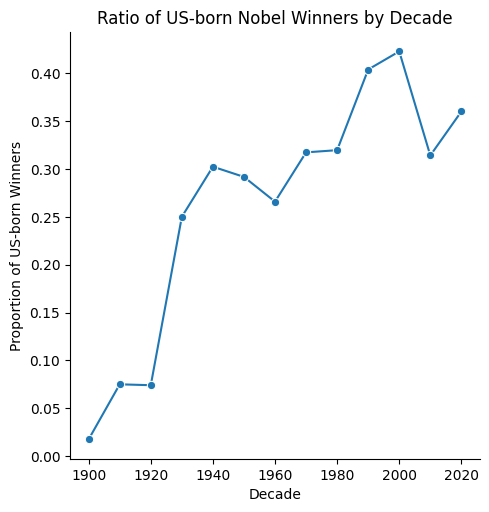

In [33]:
# Finding the ratio
ratio = nobel.groupby("decade",  as_index=False)["us_winners"].mean()
max_decade_usa = ratio.loc[ratio["us_winners"].idxmax(), "decade"]
print(f"Highest ratio of Us-born Nobel Prize winner = {max_decade_usa}")

# Vuzualizing the result
sns.relplot(data= ratio, kind= "line", x ="decade", y = "us_winners", marker = "o" )
plt.title("Ratio of US-born Nobel Winners by Decade")
plt.ylabel("Proportion of US-born Winners")
plt.xlabel("Decade")
plt.show()

In [40]:
# Highest proportion of female laureates

# Filtering for female winners
nobel["female_winner"] = nobel["sex"] == "Female"
female_ratio = nobel.groupby(["decade", "category"],  as_index=False)["female_winner"].mean()

# Find the decade and category with the highest female winners
top_row = female_ratio.loc[female_ratio["female_winner"] == female_ratio["female_winner"].max(),["decade", "category"]]

# Storing it in a dictionary
max_female_dict = {top_row["decade"].values[0]: top_row["category"].values[0]}
print(max_female_dict)

{np.int64(2020): 'Literature'}


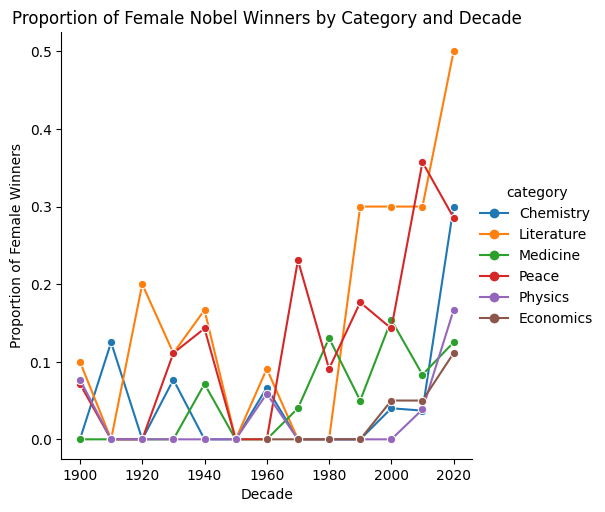

In [41]:
# Vizualizing max_female_dict
sns.relplot(data= female_ratio,x="decade", y= "female_winner", kind= "line", marker = "o", hue = "category" )
plt.title("Proportion of Female Nobel Winners by Category and Decade")
plt.ylabel("Proportion of Female Winners")
plt.xlabel("Decade")
plt.show()

In [48]:
# First woman to recieve the nobel prize.

#Filtering the dataframe
filtered_female = nobel[nobel["sex"] == "Female"]

#Finding the earliest years
first_row = filtered_female.loc[filtered_female["year"].idxmin()]

#Finding the first woman i.e. minimun value in the column
first_woman_name = first_row["full_name"]
print(first_woman_name)

# First category
first_woman_category = first_row["category"]
print(first_woman_category)

Marie Curie, née Sklodowska
Physics
